In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor

from bptf import BPTF as BPTF
import bptf

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Generate data

In [3]:
use_existing_data = True

rn.seed(0)

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :24, :]
    data = sparse.COO(data)
else:
    data = generate(shp=(200, 200, 20, 24, 3), K=10)[1]
    data = sparse.COO(data)

# Fit with BPTF

In [4]:
n_components = 50
max_iter = 500
mask = None
device = 'cuda'
tol = 1e-10

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 0]  min uttkrp_DK = 3.252e+05
[mode 0]  min new rate = 3.252e+05   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 1]  min uttkrp_DK = 7.821e+02
[mode 1]  min new rate = 7.822e+02   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 2]  min uttkrp_DK = 9.063e+03
[mode 2]  min new rate = 9.064e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 5.914e+03
[mode 3]  min new rate = 5.914e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


...

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 2.023e+03
[mode 3]  min new rate = 2.023e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 4]  min uttkrp_DK = 1.446e+04
[mode 4]  min new rate = 1.446e+04   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


100%|████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [46:00<00:00,  5.51s/it]

100%|████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [46:00<00:00,  5.52s/it]

BPTF(data_shape=(280, 280, 20, 24, 3), n_components=50)

# Fit with own BPTF_torch

In [5]:
from own_implementation import BPTF as BPTF_torch

  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]

ELBO = 18453099.50015159, change = 1.003116682151668, time taken = 0.49526429176330566:   0%|              | 0/500 [00:00<?, ?it/s]

ELBO = 18453099.50015159, change = 1.003116682151668, time taken = 0.49526429176330566:   0%|      | 1/500 [00:00<04:07,  2.01it/s]

ELBO = 18936405.696389955, change = 0.02619105783472282, time taken = 0.4953627586364746:   0%|    | 1/500 [00:00<04:07,  2.01it/s]

ELBO = 18936405.696389955, change = 0.02619105783472282, time taken = 0.4953627586364746:   0%|    | 2/500 [00:00<04:07,  2.01it/s]

...

ELBO = 40529800.04787278, change = 8.484225270313693e-08, time taken = 0.4956529140472412: 100%|▉| 499/500 [04:07<00:00,  2.01it/s]

ELBO = 40529803.270179026, change = 7.950461734992995e-08, time taken = 0.4956181049346924: 100%|▉| 499/500 [04:08<00:00,  2.01it/s

ELBO = 40529803.270179026, change = 7.950461734992995e-08, time taken = 0.4956181049346924: 100%|█| 500/500 [04:08<00:00,  2.01it/s

ELBO = 40529803.270179026, change = 7.950461734992995e-08, time taken = 0.4956181049346924: 100%|█| 500/500 [04:08<00:00,  2.01it/s

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-5920751171.33017, 18453099.50015159, 18936405.696389955, 20828511.541757837, 24416627.648899604, 28631621.556530483, 32425580.55411663, 34993695.86030046, 36533288.19292637, 37515916.82372897, 38204459.49535804, 38689441.36997719, 39030363.39330058, 39269197.95645208, 39447967.42653329, 39586916.25291141, 39702117.713963166, 39800211.25553209, 39880845.569064565, 39946106.195135504, 40000064.84974545, 40046006.29227833, 40085904.595102035, 40120518.896620095, 40150288.98043353, 40175954.93966088, 40198197.23878516, 40217568.327591434, 40234568.43138199, 40249643.44485771, 40263203.28254319, 40275601.29983501, 40287139.92729898, 40298147.52726711, 40308870.1628915, 40319294.1518955, 40329421.132468894, 40339461.506210536, 40349864.95186737, 40361197.71370059, 40374249.57370721, 40388337.672232665, 40398532.28640365, 40405945.20427793, 40412433.55664272, 40417994.17842575, 40422768.210765146,

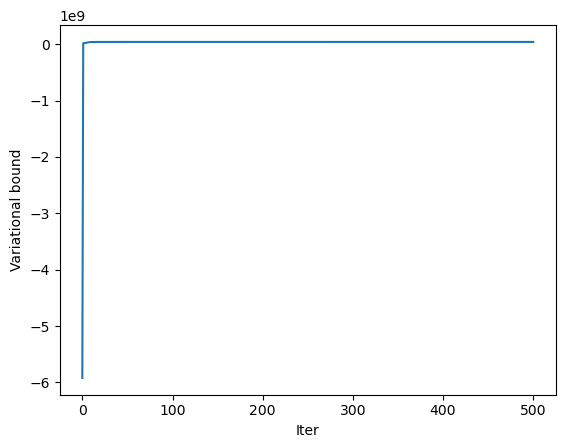

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [6]:
data = torch.tensor(data.todense(), dtype = torch.float64, device=device)
BPTF_model_torch = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model_torch.fit(data, mask = None, max_iter = max_iter, verbose=True, tol=tol)

# Check similarity

In [7]:
BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model.G_DK_M]
fro_norm_rel_diff = torch.norm(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

threshold = 0.05
diff = torch.abs(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
prop_exceed = (diff > threshold).sum().item() / diff.numel()
print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

Frobenius norm relative difference: 0.34490129224939803
Proportion of elements with difference greater than 0.05 = 0.040395390447845805


tensor(1.0668, device='cuda:0') tensor(0.1613, device='cuda:0') tensor(4467.5412, device='cuda:0')


tensor([187169, 182459, 179005, 195685, 212499, 213732, 181337, 180421, 182903,
        189020, 184379, 163428, 193436, 194318, 190057, 194417, 198240, 193003,
        191148, 175387, 197915, 206226, 191959, 182335], device='cuda:0')


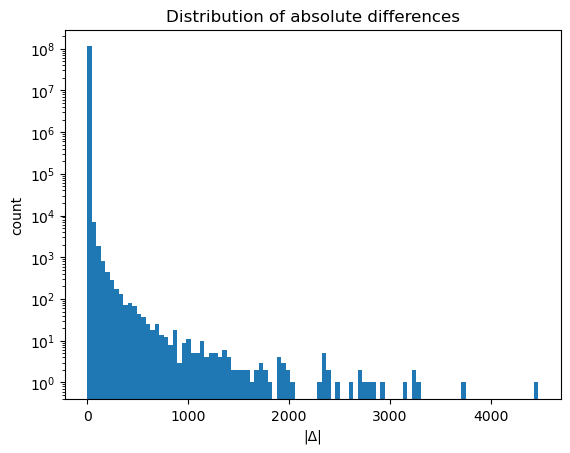

In [8]:
# 1) How big are the large errors?
big = diff[diff > 0.05]
print(big.mean(), big.median(), big.max())

# 2) Histogram of the absolute differences
import matplotlib.pyplot as plt
plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')

# 3) Where do they occur?  Example for mode-4 time slices
exceed_mask = (diff > 0.05)
time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
print(time_exceed)  # counts per month